# DEF-D Fysieke Ontwerpopdracht 2 invul template

## Groep informatie

Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in (als in *PR* op GitHub en de link op Brightspace). Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 67     |  |
| :-------------|:-------------|
| Tijn Kraan    | 6566499      |
| Planning Groep: 67     |Tijdstip / Tijdspanne  |
| Mijlpaal 1 | Condensator gemaakt en getest 12:45 |
|Eerste metingen aan sensor|15:30/16:00|
| Mijlpaal 2 | Sensor gemaakt en getest 17:00 |
| Harde deadline|17:30 opgeruimd en klaar|
| groep aanwezig 1| 10:45 - 12:45 |
| groep aanwezig 2| 13:45 - eind |
| Pauze 1| 1 uur om 12:45 |
| Pauze 2| 15 min 15:00 |

## *Opdracht 1*: Sanity check 3

#### Voeg hier een foto van de schets van je plaatcondensator in. Geef daarbij ook duidelijk de waarde van $A$ en $d$ aan.
<img src="schets.jpg" alt="schets student 1" width="400"/>

In [11]:
# Schrijf hier een python functie die de capaciteit van een plaatcondensator uitrekent. Zorg dat de functie
# als input de ontwerpparameters van de vlakke plaat formule accepteert (oppervlakte, afstand en diëlektrische
# constante) en als output de capaciteit van de vlakke plaat condensator met die ontwerpparameters.
# Je gaat deze formule de rest van de dag gebruiken: controleer hem goed!

epsilon0 = 8.854e-12  # permittiviteit van vacuum (F/m)
epsilonR = 2.3
A = 0.01
def vlakkeplaat(d):
    C = ((epsilon0 *epsilonR* A) / (d*10**-3))*10**12
    return C


# Optioneel: schrijf je functie zodanig dat je arrays als input kan geven en (dus) ook arrays als output.

In [12]:
# Gebruik je formule om uit te rekenen wat je verwacht dat de capaciteit van jullie vlakke plaat condensatoren
# gaat zijn.

C = vlakkeplaat(2.0)


print(f"Berekende capaciteit plaatcondensator is {C:.1f} pF")



Berekende capaciteit plaatcondensator is 101.8 pF


#### Voeg hier een foto van je plaatcondensator en van de meting op de scope in. Dus 2 foto's.
![scope meting 1](scope_test.jpg)
![scope meting 2](test_C.jpg)

### Meting capaciteit
Vul onderstaande tabel in. Bij Sanity check 2 heb je afgeleid hoe je van berekende capaciteit naar berekend voltage gaat en terug. 


| Namen         | Berekende capaciteit   | Berekend Voltage | Gemeten Voltage | Gemeten capaciteit   |
|-------------|-------------:|-------------:|-------------:|-------------:|
| groep Inhalen | 123 pF |  6V | 0.72 V | 144pF |

## *Opdracht 2:* Synthese.

#### Voeg hier voor een foto van je schets(en) van minimaal drie sensoren in.
![drie schetsen](Schets_1.jpeg)


## Opdracht 3: Welke sensor gaan jullie maken?

Pas deze tekst aan: Wij gaan een gewicht-sensor maken die massa meet.

## Opdracht 4: Uitgewerkte schets (afmetingen!) en plot van de ontwerpgrafiek.

#### Voeg hier een foto van jullie uitgewerkte  schets van de sensor die jullie gaan maken in
![uitgewerkte schets](schets_2.jpeg)

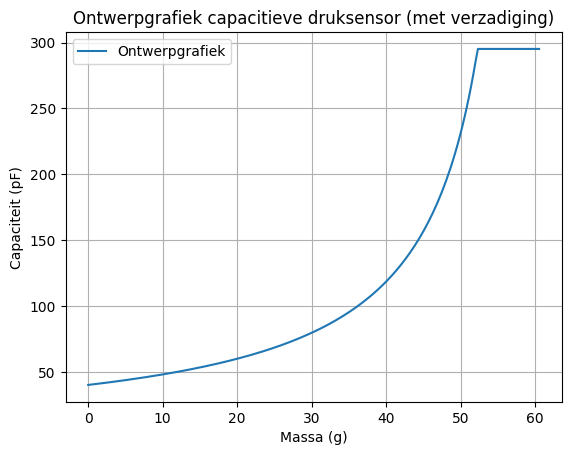

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Constanten
epsilon0 = 8.854e-12   # F/m
epsilonR = 1.0
A = 0.01              # m^2

# Afstanden (mm)
d0 = 2.2                # beginafstand
d_min = 0.3            # minimale afstand (mechanische stop!)

# Doorbuiging (mm)
doorbuiging = np.linspace(0, 2.2, 200)

# Effectieve plaatafstand met limiet
d = np.maximum(d0 - doorbuiging, d_min)

# Massa (kg → g)
k = 270               # N/m (effectieve veerconstante)
Massa = (k * doorbuiging * 1e-3) / 9.81
Massa = Massa * 1000   # g

# Capaciteit
def vlakkeplaatfit(d_mm):
    d_m = d_mm * 1e-3
    C = epsilon0 * epsilonR * A / d_m
    return C * 1e12     # pF

Capaciteit = vlakkeplaatfit(d)

# Plot
plt.plot(Massa, Capaciteit, label='Ontwerpgrafiek')
plt.xlabel('Massa (g)')
plt.ylabel('Capaciteit (pF)')
plt.title('Ontwerpgrafiek capacitieve druksensor (met verzadiging)')
plt.grid()
plt.legend()
plt.savefig('fit_fig.png', dpi=300)
plt.show()

## Opdracht 5: Invullen tabel LTSpice.

|         | Capaciteit waarde (pF)  | LTSpice berekend output Vpp (mV)|
|-------------|-------------:|-------------:|
| minmale capaciteit| 40 | 201 |
| gemiddelde capaciteit| 66 | 331 |
| maximale capaciteit| 177 | 884 |

## Opdracht 6: Foto's werkende opstelling.

#### Voeg hier de foto's van je sensoren in actie in.
![meting 1](Cal_ops_1.jpeg)
![meting 1](Cal_fig_1.jpeg)
![meting 2](Cal_ops_2.jpeg)
![meting 2](Cal_fig_2.jpeg)

## Opdracht 7: Plot de kalibratiegrafiek.

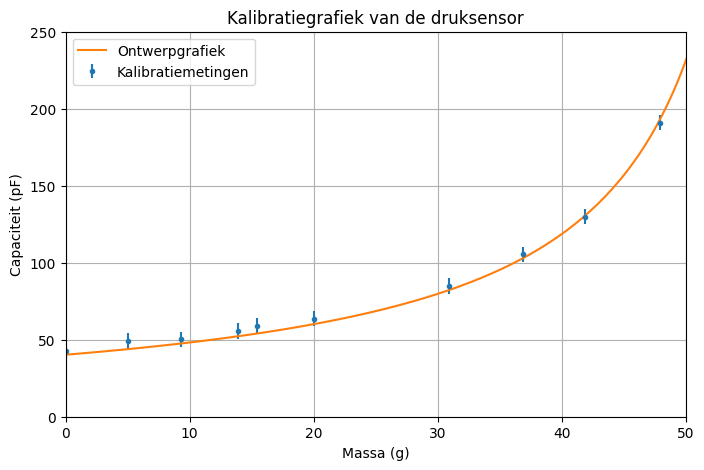

In [14]:
# Plot hier je gemeten kalibratiegrafiek en plot in dezelfde figuur ook je verwachte ontwerpgrafiek.
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

d0 = 2.2                # beginafstand (mm)
volt_bron = 8          # V
R = 1000               # Ohm
frequentie = 100000      # Hz

massa_kalibratie = np.array([0, 5, 9.3, 13.9, 20, 15.4, 30.9, 36.9, 47.9, 41.9]) #g
massa_tot_20_g = np.array([0, 5, 9.3, 13.9, 20, 15.4]) #g

capaciteit_kalibratie = np.array([42.4, 49.1, 50.3, 55.7, 63.7, 59.1, 84.9, 105.4, 191.0, 130.0 ]) #pF
capaciteit_tot_20_g = np.array([42.4, 49.1, 50.3, 55.7, 63.7, 59.1]) #pF

onzekerheid_C = 5 # pF

plt.figure(figsize=(8, 5))
plt.errorbar(massa_kalibratie, capaciteit_kalibratie, yerr=onzekerheid_C, fmt='.', label='Kalibratiemetingen')
plt.plot(Massa, Capaciteit, label='Ontwerpgrafiek')
plt.xlim(0, 50)
plt.ylim(0, 250)
plt.xlabel('Massa (g)')
plt.ylabel('Capaciteit (pF)')
plt.title('Kalibratiegrafiek van de druksensor')
plt.grid()
plt.legend()
plt.savefig('kal_fig_1.png', dpi=300)
plt.show()

## Opdracht 8: Vul de tekst aan.

Onze sensor kan nog verbetered worden door de volgende verbeteringen (minimaal 2):

* verbetering 1:
De platen zaten niet elke keer recht boven elkaar, en het verschil hiertussen veranderde ook elke keer waardoor dus ook de capciteit elke keer een andere afwijking heeft. Om dit tegen te gaan moet de opstelling zo zijn dat ze elke keer precies boven elkaar hangen.

* verbetering 2:
Doordat de gewichten niet elke keer precies in het midden lagen hing de bovenste plaat schuin waardoor de capaciteit elke keer er net naast zat, omdat de gewcihten bij alle metingen op verschilende plekken lagen was dit niet elke keer hezelfde en zit elke meting er op een andere hoeveelheid naast

## Opdracht 9: Uiteindelijke ontwerp en kalibratiegrafiek.

#### Voeg hier een foto van je uiteindelijke sensor in.
![foto sensor](Ops.jpeg)

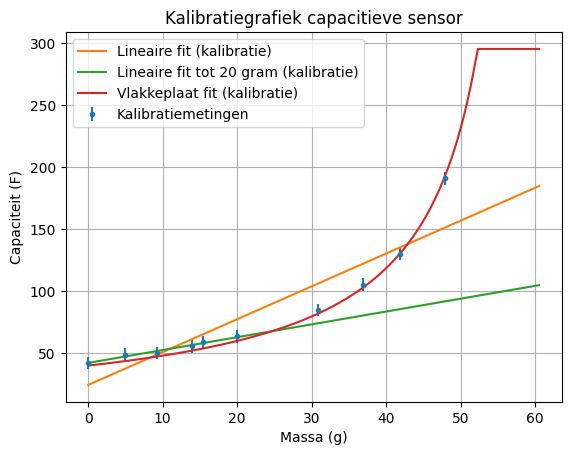

In [15]:
# Plot hier je oorspronkelijke en je uiteindelijke kalibratiegrafieken, fit daar een bijpassende lijn door
# en zet ook de verwachte ontwerpgrafiek erbij

def lineairfit(x,a,b):
    return a*x + b

popt, pcov = curve_fit(lineairfit, massa_kalibratie, capaciteit_kalibratie)
popt2, pcov2 = curve_fit(lineairfit, massa_tot_20_g, capaciteit_tot_20_g)

plt.figure()
plt.errorbar(massa_kalibratie, capaciteit_kalibratie,yerr=onzekerheid_C, fmt='.', label='Kalibratiemetingen')
plt.plot(Massa, lineairfit(Massa, *popt), label='Lineaire fit (kalibratie)')
plt.plot(Massa, lineairfit(Massa, *popt2), label='Lineaire fit tot 20 gram (kalibratie)')
plt.plot(Massa, Capaciteit,label='Vlakkeplaat fit (kalibratie)')
plt.xlabel('Massa (g)')
plt.ylabel('Capaciteit (F)')
plt.title('Kalibratiegrafiek capacitieve sensor')
plt.grid()
plt.legend()
plt.savefig('kal_fig_2.png', dpi=300)
plt.show()

## Opdracht 10: Vul hieronder de conclusie in.

In deze proef is gekeken naar de verandering in capaciteit bij verandering in massa. Dit is gedaan door de bovenste plaat van de condensator aan elastieken te hangen en hier massa op te leggen. Door deze toegevoegde massa zal het elastiek uitrekken naar de onderste plaat en zal dus de afstand tussen deze verkleinen. Door deze kleinere afstand zal de capaciteit van de condensator toenemen. De data die uit de metingen kwam leek erg op de eerder gemaakte fit, echter komt het niet overeen met de lineare fit over 50 gram, wel zou dit verband tot 20 gram genomen kunnen worden. Dit komt ook omdat de Vlakkeplaat fit tot daar bijna linear is. Wel de onzekerheid te groot om op dit gebied metingen te doen wat op het gebied daarna wel mogelijk is, (bij een massa boven de 20 gram).

De conclusie is dan ook dat deze opstelling niet precies genoeg is om de massa nauwkeurig te meten op het eerste domein (tot 20 gram) domein. Wel zijn hogere waarden beter zouden kloppen, doordat de onzekerheid rond de vijf pF is gebleven bij de metingen. Om de metingen te verbeteren in vervolgonderzoeken zijn de stabiliteit van de opstelling en nauwkeurigheid de belangrijkste onderdelen. Dit kan vrij eenvoudig door grotere platen te gebruiken, hierdoor kan ook tot grotere massa's gemeten worden (Dit zou ook met meer elastieken bereikt kunnen worden). De nauwkeurigheid zal het beste zijn in het gebied waar de steiging het grootste is. Doordat daar het verschil tussen capaciteiten het grootste is.

## Opdracht 11: Kopieer hieronder de leerdoelen.
1. Het kunnen gebruiken van de eigenschappen van een elektrische component in een ontwerpproces om een fysische grootheid te meten.
2. Kennis hebben van gedrag van elektrische componenten en meetopstellingen.
3. Onderdelen van een datasheet zoals een kalibratiegrafiek opstellen, gevoeligheid en onzekerheid beschrijven.

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 1 beheersen.
![uitgewerkte schets](Schets_1.jpeg)
![uitgewerkte schets](schets_2.jpeg)
![uitgewerkte schets](kal_fig_1.png)

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 2 beheersen.
![scope meting 1](Cal_fig_1.jpeg)
![scope meting 1](Cal_fig_2.jpeg)
![scope meting 1](Cal_ops_1.jpeg)
![scope meting 1](Cal_ops_2.jpeg)


kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 3 beheersen.
![uitgewerkte schets](fit_fig.png)
![uitgewerkte schets](kal_fig_1.png)